# TabR tuning notebook — question time-aware splits

Eksperimen:
1. hold-out chronological by question: train q1-q3, val q4, test q5
2. walk-forward by question fold A: train q1-q2, val q3, test q4
3. walk-forward by question fold B: train q1-q3, val q4, test q5

Prinsip:
- pakai fitur apex asli, tanpa PCA/LDA/4QMV
- pakai base tuning config yang sama
- output dataset/exp baru, tidak replace hasil lama
- `force=False`, jadi run existing akan skip/error, bukan overwrite


In [1]:
from __future__ import annotations

import copy
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from scipy.special import expit
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from tensorboard.backend.event_processing import event_accumulator

sns.set_theme(style='whitegrid')
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

TABR_ROOT = ROOT / 'third_party' / 'tabular-dl-tabr-official'
os.environ['PROJECT_DIR'] = str(TABR_ROOT)
os.environ.setdefault('CUDA_VISIBLE_DEVICES', '0')
if str(TABR_ROOT) not in sys.path:
    sys.path.append(str(TABR_ROOT))

import lib
import bin.go

FEATURES_PATH = ROOT / 'output' / 'apex' / 'features' / 'poc_abs_mata_alis_mulut.xlsx'
BASE_TUNING_TOML = TABR_ROOT / 'exp' / 'tabr' / 'convat_apex_anxiety' / '0-tuning.toml'
DATA_ROOT = TABR_ROOT / 'data'
EXP_ROOT = TABR_ROOT / 'exp' / 'tabr'

N_EVAL_SEEDS = 15
N_ENSEMBLES = 3
ENSEMBLE_SIZE = 5
RESET_NEW_OUTPUTS = False

LABEL_MAP = {'anxiety_rendah': 0, 'anxiety_tinggi': 1}
LABEL_NAMES = ['anxiety_rendah', 'anxiety_tinggi']
META_COLS = [
    'phase', 'condition', 'label', 'participant', 'participant_raw', 'question', 'question_no',
    'sample', 'clip', 'event_clip', 'event_no', 'clip_path', 'frame', 'target', 'event_id',
]
EXPERIMENTS = [
    {
        'mode': 'qholdout',
        'dataset_name': 'convat_apex_anxiety_qholdout_q123_q4_q5_alis',
        'exp_name': 'convat_apex_anxiety_qholdout_q123_q4_q5_alis',
        'train_questions': (1, 2, 3),
        'val_questions': (4,),
        'test_questions': (5,),
    },
    {
        'mode': 'qwalkforward',
        'dataset_name': 'convat_apex_anxiety_qwalk_q12_q3_q4_alis',
        'exp_name': 'convat_apex_anxiety_qwalk_q12_q3_q4_alis',
        'train_questions': (1, 2),
        'val_questions': (3,),
        'test_questions': (4,),
    },
    {
        'mode': 'qwalkforward',
        'dataset_name': 'convat_apex_anxiety_qwalk_q123_q4_q5_alis',
        'exp_name': 'convat_apex_anxiety_qwalk_q123_q4_q5_alis',
        'train_questions': (1, 2, 3),
        'val_questions': (4,),
        'test_questions': (5,),
    },
]

display(Markdown(f'- ROOT: `{ROOT}`\n- FEATURES: `{FEATURES_PATH}`\n- BASE_TUNING_TOML: `{BASE_TUNING_TOML}`'))


- ROOT: `/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st`
- FEATURES: `/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/features/poc_abs_mata_alis_mulut.xlsx`
- BASE_TUNING_TOML: `/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/third_party/tabular-dl-tabr-official/exp/tabr/convat_apex_anxiety/0-tuning.toml`

In [2]:
if not FEATURES_PATH.exists():
    raise FileNotFoundError(FEATURES_PATH)
if not BASE_TUNING_TOML.exists():
    raise FileNotFoundError(BASE_TUNING_TOML)

df_raw = pd.read_excel(FEATURES_PATH)
df_raw = df_raw[df_raw['label'].isin(LABEL_MAP)].copy()
df_raw['target'] = df_raw['label'].map(LABEL_MAP).astype(int)
df_raw['event_id'] = (
    df_raw['phase'].astype(str) + '||'
    + df_raw['participant'].astype(str) + '||'
    + df_raw['question'].astype(str) + '||'
    + df_raw['clip'].astype(str) + '||'
    + df_raw['event_clip'].astype(str)
)
FEATURE_COLS = [c for c in df_raw.columns if c not in META_COLS]
print('rows:', len(df_raw))
print('feature cols:', len(FEATURE_COLS))
print(df_raw['label'].value_counts().to_dict())
display(df_raw[['phase', 'participant', 'question', 'question_no', 'clip', 'event_clip', 'label']].head(2))


rows: 57656
feature cols: 608
{'anxiety_tinggi': 35980, 'anxiety_rendah': 21676}


,phase,participant,question,question_no,clip,event_clip,label
0,before,aaisyah_nursalsabiil_ni_patriarti,q1,1,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00054-00095,anxiety_tinggi
1,before,aaisyah_nursalsabiil_ni_patriarti,q1,1,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00054-00095,anxiety_tinggi


In [3]:
def split_by_questions(df: pd.DataFrame, train_questions: tuple[int, ...], val_questions: tuple[int, ...], test_questions: tuple[int, ...]) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    event_table = df[['event_id', 'question_no']].drop_duplicates().reset_index(drop=True)
    train_event_ids = set(event_table[event_table['question_no'].isin(train_questions)]['event_id'])
    val_event_ids = set(event_table[event_table['question_no'].isin(val_questions)]['event_id'])
    test_event_ids = set(event_table[event_table['question_no'].isin(test_questions)]['event_id'])
    df_train = df[df['event_id'].isin(train_event_ids)].copy()
    df_val = df[df['event_id'].isin(val_event_ids)].copy()
    df_test = df[df['event_id'].isin(test_event_ids)].copy()
    return df_train, df_val, df_test


def export_official_dataset(df: pd.DataFrame, feature_cols: list[str], cfg: dict, overwrite_existing: bool = True, reset_existing: bool = RESET_NEW_OUTPUTS) -> dict:
    out_dir = DATA_ROOT / cfg['dataset_name']
    if out_dir.exists() and not overwrite_existing:
        if reset_existing:
            raise RuntimeError('RESET_NEW_OUTPUTS intentionally disabled in this notebook template')
        raise FileExistsError(f'Dataset dir already exists: {out_dir}')

    df_tr, df_val, df_test = split_by_questions(df, cfg['train_questions'], cfg['val_questions'], cfg['test_questions'])

    imputer = SimpleImputer(strategy='mean')
    scaler = StandardScaler()
    X_train = scaler.fit_transform(imputer.fit_transform(df_tr[feature_cols])).astype(np.float32)
    X_val = scaler.transform(imputer.transform(df_val[feature_cols])).astype(np.float32)
    X_test = scaler.transform(imputer.transform(df_test[feature_cols])).astype(np.float32)
    y_train = df_tr['target'].to_numpy(dtype=np.int64)
    y_val = df_val['target'].to_numpy(dtype=np.int64)
    y_test = df_test['target'].to_numpy(dtype=np.int64)

    out_dir.mkdir(parents=True, exist_ok=True)
    np.save(out_dir / 'X_num_train.npy', X_train)
    np.save(out_dir / 'X_num_val.npy', X_val)
    np.save(out_dir / 'X_num_test.npy', X_test)
    np.save(out_dir / 'Y_train.npy', y_train)
    np.save(out_dir / 'Y_val.npy', y_val)
    np.save(out_dir / 'Y_test.npy', y_test)
    (out_dir / 'READY').write_text('')
    (out_dir / 'info.json').write_text(json.dumps({'task_type': 'binclass', 'name': cfg['dataset_name'], 'id': cfg['dataset_name']}, indent=2))
    (out_dir / 'feature_cols.json').write_text(json.dumps(feature_cols, indent=2))
    df_tr.to_csv(out_dir / 'train_split.csv', index=False)
    df_val.to_csv(out_dir / 'val_split.csv', index=False)
    df_test.to_csv(out_dir / 'test_split.csv', index=False)
    return {
        'dataset_dir': out_dir,
        'df_train': df_tr,
        'df_val': df_val,
        'df_test': df_test,
        'X_train': X_train,
        'X_val': X_val,
        'X_test': X_test,
        'y_train': y_train,
        'y_val': y_val,
        'y_test': y_test,
    }


def prepare_tuning_config(dataset_name: str, exp_name: str, overwrite_existing: bool = True) -> tuple[dict, Path]:
    config = lib.load_config(BASE_TUNING_TOML)
    config = copy.deepcopy(config)
    config['space']['data']['path'] = f':data/{dataset_name}'
    exp_dir = EXP_ROOT / exp_name
    tuning_toml = exp_dir / '0-tuning.toml'
    if tuning_toml.exists() and not overwrite_existing:
        raise FileExistsError(f'Experiment path already exists: {exp_dir}')
    exp_dir.mkdir(parents=True, exist_ok=True)
    lib.dump_config(config, tuning_toml)
    return config, tuning_toml


def load_split_info_from_dataset(dataset_dir: Path) -> dict:
    df_train = pd.read_csv(dataset_dir / 'train_split.csv')
    df_val = pd.read_csv(dataset_dir / 'val_split.csv')
    df_test = pd.read_csv(dataset_dir / 'test_split.csv')
    return {
        'dataset_dir': dataset_dir,
        'df_train': df_train,
        'df_val': df_val,
        'df_test': df_test,
        'y_train': df_train['target'].to_numpy(dtype=np.int64),
        'y_val': df_val['target'].to_numpy(dtype=np.int64),
        'y_test': df_test['target'].to_numpy(dtype=np.int64),
    }


In [4]:
def load_scalar_series(run_dir: Path, tag_dir: str, tag: str) -> pd.DataFrame:
    event_file = next((run_dir / tag_dir).glob('events.out.tfevents.*'))
    ea = event_accumulator.EventAccumulator(str(event_file))
    ea.Reload()
    scalars = ea.Scalars(tag)
    return pd.DataFrame({
        'epoch': [x.step for x in scalars],
        'value': [x.value for x in scalars],
        'wall_time': [x.wall_time for x in scalars],
    })


def collect_epoch_metrics(run_dir: Path) -> pd.DataFrame:
    checkpoint = lib.load_checkpoint(run_dir, map_location='cpu')
    rows = []
    for item in checkpoint['training_log']:
        metrics = item['metrics']
        rows.append({
            'epoch': len(rows),
            'val_loss': float(metrics['val'].get('cross-entropy', np.nan)),
            'test_loss': float(metrics['test'].get('cross-entropy', np.nan)),
            'val_acc': float(metrics['val']['score']),
            'test_acc': float(metrics['test']['score']),
        })
    epoch_df = pd.DataFrame(rows)
    train_loss = load_scalar_series(run_dir, 'loss_train', 'loss')
    epoch_df = epoch_df.merge(train_loss[['epoch', 'value']].rename(columns={'value': 'train_loss'}), on='epoch', how='left')
    return epoch_df


def infer_train_accuracy_from_predictions(run_dir: Path, y_train: np.ndarray) -> float:
    preds = lib.load_predictions(run_dir)
    train_logits = preds['train']
    train_prob = expit(train_logits)
    train_pred = (train_prob >= 0.5).astype(int)
    return float((train_pred == y_train).mean())


def make_confusion_df(y_true: np.ndarray, y_pred: np.ndarray) -> pd.DataFrame:
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    return pd.DataFrame(cm, index=['true_anxiety_rendah', 'true_anxiety_tinggi'], columns=['pred_anxiety_rendah', 'pred_anxiety_tinggi'])


def evaluate_best_run(run_dir: Path, split_info: dict) -> dict:
    preds = lib.load_predictions(run_dir)
    out = {}
    for part, y_true in [('train', split_info['y_train']), ('val', split_info['y_val']), ('test', split_info['y_test'])]:
        logits = preds[part]
        prob = expit(logits)
        pred = (prob >= 0.5).astype(int)
        out[part] = {
            'y_true': y_true,
            'prob': prob,
            'pred': pred,
            'report': classification_report(y_true, pred, target_names=LABEL_NAMES, output_dict=True),
            'cm_df': make_confusion_df(y_true, pred),
        }
    out['report_json'] = json.loads((run_dir / 'report.json').read_text())
    out['summary_json'] = json.loads((run_dir / 'summary.json').read_text())
    out['epoch_df'] = collect_epoch_metrics(run_dir)
    out['final_train_acc'] = infer_train_accuracy_from_predictions(run_dir, split_info['y_train'])
    return out


def plot_training_curves(result: dict, title_prefix: str) -> None:
    epoch_df = result['epoch_df'].copy()
    best_epoch = int(result['report_json']['best_epoch'])
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epoch_df['epoch'], epoch_df['train_loss'], marker='o', label='train_loss')
    axes[0].plot(epoch_df['epoch'], epoch_df['val_loss'], marker='o', label='val_loss')
    axes[0].axvline(best_epoch, linestyle='--', color='red', label=f'best_epoch={best_epoch}')
    axes[0].set_title(f'{title_prefix} loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[1].plot(epoch_df['epoch'], epoch_df['val_acc'], marker='o', label='val_acc')
    axes[1].plot(epoch_df['epoch'], epoch_df['test_acc'], marker='o', label='test_acc')
    axes[1].axhline(result['final_train_acc'], linestyle=':', color='green', label=f"train_acc_final={result['final_train_acc']:.3f}")
    axes[1].axvline(best_epoch, linestyle='--', color='red', label=f'best_epoch={best_epoch}')
    axes[1].set_title(f'{title_prefix} accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_ylim(0, 1)
    axes[1].legend()
    plt.tight_layout()
    plt.show()


def plot_confusions(result: dict, title_prefix: str) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, part, title in zip(axes, ['val', 'test'], ['Validation', 'Test']):
        sns.heatmap(result[part]['cm_df'], annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
        ax.set_title(f'{title_prefix} {title}')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
    plt.tight_layout()
    plt.show()


def summarize_result(cfg: dict, result: dict, best_seed: int) -> pd.DataFrame:
    rows = []
    for part, part_name in [('train', 'train'), ('val', 'val'), ('test', 'test')]:
        report = result[part]['report']
        rows.append({
            'mode': cfg['mode'],
            'dataset_name': cfg['dataset_name'],
            'exp_name': cfg['exp_name'],
            'train_questions': '-'.join(map(str, cfg['train_questions'])),
            'val_questions': '-'.join(map(str, cfg['val_questions'])),
            'test_questions': '-'.join(map(str, cfg['test_questions'])),
            'split': part_name,
            'accuracy': report['accuracy'],
            'macro_f1': report['macro avg']['f1-score'],
            'weighted_f1': report['weighted avg']['f1-score'],
            'precision_tinggi': report['anxiety_tinggi']['precision'],
            'recall_tinggi': report['anxiety_tinggi']['recall'],
            'best_epoch': result['report_json']['best_epoch'],
            'best_seed': best_seed,
        })
    return pd.DataFrame(rows)


def evaluate_experiment(cfg: dict) -> tuple[pd.DataFrame, dict]:
    dataset_dir = DATA_ROOT / cfg['dataset_name']
    split_info = load_split_info_from_dataset(dataset_dir)
    eval_dir = EXP_ROOT / cfg['exp_name'] / '0-evaluation'
    best_seed = max(
        range(N_EVAL_SEEDS),
        key=lambda s: json.loads((eval_dir / str(s) / 'report.json').read_text())['metrics']['val']['score'],
    )
    best_run_dir = eval_dir / str(best_seed)
    result = evaluate_best_run(best_run_dir, split_info)
    summary = summarize_result(cfg, result, best_seed)
    return summary, {
        'cfg': cfg,
        'best_seed': best_seed,
        'best_run_dir': best_run_dir,
        'result': result,
    }


## Experiment 1 — qholdout q123/q4/q5


In [6]:
cfg_qholdout = EXPERIMENTS[0]
split_info_qholdout = export_official_dataset(df_raw, FEATURE_COLS, cfg_qholdout)
_config_qholdout, tuning_toml_qholdout = prepare_tuning_config(cfg_qholdout['dataset_name'], cfg_qholdout['exp_name'])
display(Markdown(
    f"Prepared `{cfg_qholdout['dataset_name']}` / `{cfg_qholdout['exp_name']}`\n\n"
    f"- train: `{cfg_qholdout['train_questions']}`\n"
    f"- val: `{cfg_qholdout['val_questions']}`\n"
    f"- test: `{cfg_qholdout['test_questions']}`\n"
    f"- tuning: `{tuning_toml_qholdout}`"
))
del split_info_qholdout


Prepared `convat_apex_anxiety_qholdout_q123_q4_q5_alis` / `convat_apex_anxiety_qholdout_q123_q4_q5_alis`

- train: `(1, 2, 3)`
- val: `(4,)`
- test: `(5,)`
- tuning: `/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/third_party/tabular-dl-tabr-official/exp/tabr/convat_apex_anxiety_qholdout_q123_q4_q5_alis/0-tuning.toml`

In [ ]:
bin.go.main(
    tuning_toml_qholdout,
    n_seeds=N_EVAL_SEEDS,
    n_ensembles=N_ENSEMBLES,
    ensemble_size=ENSEMBLE_SIZE,
    continue_=True,
    force=False,
)


In [8]:
print('RUN:', cfg_qholdout['exp_name'])


RUN: convat_apex_anxiety_qholdout_q123_q4_q5_alis


In [9]:
summary_qholdout, result_qholdout = evaluate_experiment(cfg_qholdout)
display(summary_qholdout.sort_values(['split', 'accuracy'], ascending=[True, False]))


,mode,dataset_name,exp_name,train_questions,val_questions,test_questions,split,accuracy,macro_f1,weighted_f1,precision_tinggi,recall_tinggi,best_epoch,best_seed
2,qholdout,convat_apex_anxiety_qholdout_q123_q4_q5_alis,convat_apex_anxiety_qholdout_q123_q4_q5_alis,1-2-3,4,5,test,0.828686,0.813201,0.828862,0.869183,0.864797,64,11
0,qholdout,convat_apex_anxiety_qholdout_q123_q4_q5_alis,convat_apex_anxiety_qholdout_q123_q4_q5_alis,1-2-3,4,5,train,0.999108,0.999055,0.999108,0.999594,0.998962,64,11
1,qholdout,convat_apex_anxiety_qholdout_q123_q4_q5_alis,convat_apex_anxiety_qholdout_q123_q4_q5_alis,1-2-3,4,5,val,0.839556,0.829281,0.839667,0.873016,0.869320,64,11


In [10]:
ensemble_rows_qholdout = []
ensemble_root_qholdout = EXP_ROOT / cfg_qholdout['exp_name'] / f'0-ensemble-{ENSEMBLE_SIZE}'
if ensemble_root_qholdout.exists():
    for ensemble_dir in sorted([x for x in ensemble_root_qholdout.iterdir() if x.is_dir()]):
        report_path = ensemble_dir / 'report.json'
        if not report_path.exists():
            continue
        report = json.loads(report_path.read_text())
        ensemble_rows_qholdout.append({
            'exp_name': cfg_qholdout['exp_name'],
            'ensemble_id': ensemble_dir.name,
            'train_score': report['metrics']['train']['score'],
            'val_score': report['metrics']['val']['score'],
            'test_score': report['metrics']['test']['score'],
        })
ensemble_df_qholdout = pd.DataFrame(ensemble_rows_qholdout)
if len(ensemble_df_qholdout):
    display(ensemble_df_qholdout.sort_values(['test_score', 'val_score'], ascending=False))
else:
    print('Belum ada output ensemble.')


,exp_name,ensemble_id,train_score,val_score,test_score
0,convat_apex_anxiety_qholdout_q123_q4_q5_alis,0,0.999972,0.862011,0.857430
1,convat_apex_anxiety_qholdout_q123_q4_q5_alis,1,1.000000,0.859281,0.854460
2,convat_apex_anxiety_qholdout_q123_q4_q5_alis,2,1.000000,0.857432,0.854173


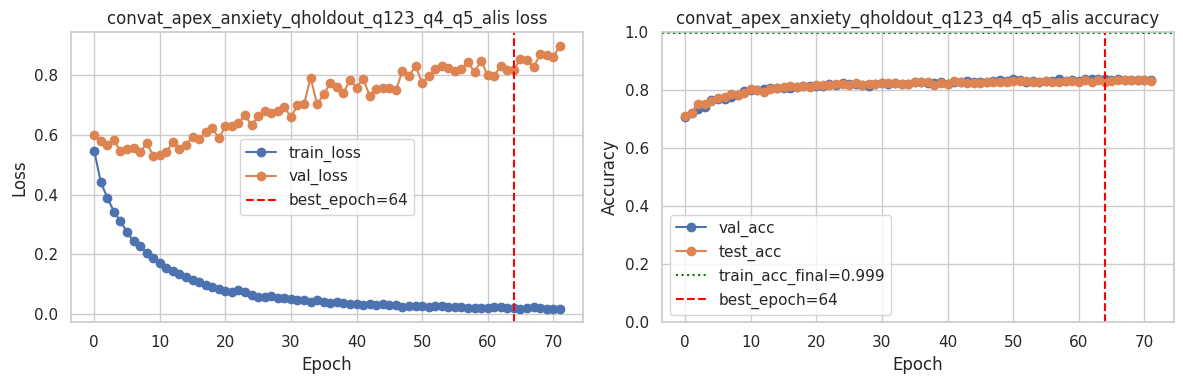

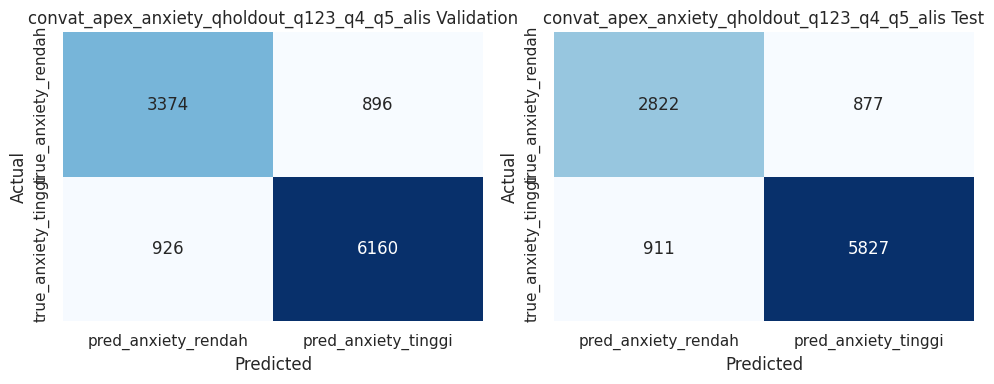

In [11]:
plot_training_curves(result_qholdout['result'], cfg_qholdout['exp_name'])
plot_confusions(result_qholdout['result'], cfg_qholdout['exp_name'])


## Experiment 2 — qwalk q12/q3/q4


In [5]:
cfg_qwalk_a = EXPERIMENTS[1]
split_info_qwalk_a = export_official_dataset(df_raw, FEATURE_COLS, cfg_qwalk_a)
_config_qwalk_a, tuning_toml_qwalk_a = prepare_tuning_config(cfg_qwalk_a['dataset_name'], cfg_qwalk_a['exp_name'])
display(Markdown(
    f"Prepared `{cfg_qwalk_a['dataset_name']}` / `{cfg_qwalk_a['exp_name']}`\n\n"
    f"- train: `{cfg_qwalk_a['train_questions']}`\n"
    f"- val: `{cfg_qwalk_a['val_questions']}`\n"
    f"- test: `{cfg_qwalk_a['test_questions']}`\n"
    f"- tuning: `{tuning_toml_qwalk_a}`"
))
del split_info_qwalk_a


Prepared `convat_apex_anxiety_qwalk_q12_q3_q4_alis` / `convat_apex_anxiety_qwalk_q12_q3_q4_alis`

- train: `(1, 2)`
- val: `(3,)`
- test: `(4,)`
- tuning: `/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/third_party/tabular-dl-tabr-official/exp/tabr/convat_apex_anxiety_qwalk_q12_q3_q4_alis/0-tuning.toml`

In [ ]:
print('RUN:', cfg_qwalk_a['exp_name'])
bin.go.main(
    tuning_toml_qwalk_a,
    n_seeds=N_EVAL_SEEDS,
    n_ensembles=N_ENSEMBLES,
    ensemble_size=ENSEMBLE_SIZE,
    continue_=True,
    force=False,
)


In [7]:
summary_qwalk_a, result_qwalk_a = evaluate_experiment(cfg_qwalk_a)
display(summary_qwalk_a.sort_values(['split', 'accuracy'], ascending=[True, False]))


,mode,dataset_name,exp_name,train_questions,val_questions,test_questions,split,accuracy,macro_f1,weighted_f1,precision_tinggi,recall_tinggi,best_epoch,best_seed
2,qwalkforward,convat_apex_anxiety_qwalk_q12_q3_q4_alis,convat_apex_anxiety_qwalk_q12_q3_q4_alis,1-2,3,4,test,0.796055,0.777542,0.793455,0.816061,0.869038,53,8
0,qwalkforward,convat_apex_anxiety_qwalk_q12_q3_q4_alis,convat_apex_anxiety_qwalk_q12_q3_q4_alis,1-2,3,4,train,0.999517,0.999490,0.999517,0.999347,0.999869,53,8
1,qwalkforward,convat_apex_anxiety_qwalk_q12_q3_q4_alis,convat_apex_anxiety_qwalk_q12_q3_q4_alis,1-2,3,4,val,0.801835,0.782499,0.798407,0.814197,0.883314,53,8


In [8]:
ensemble_rows_qwalk_a = []
ensemble_root_qwalk_a = EXP_ROOT / cfg_qwalk_a['exp_name'] / f'0-ensemble-{ENSEMBLE_SIZE}'
if ensemble_root_qwalk_a.exists():
    for ensemble_dir in sorted([x for x in ensemble_root_qwalk_a.iterdir() if x.is_dir()]):
        report_path = ensemble_dir / 'report.json'
        if not report_path.exists():
            continue
        report = json.loads(report_path.read_text())
        ensemble_rows_qwalk_a.append({
            'exp_name': cfg_qwalk_a['exp_name'],
            'ensemble_id': ensemble_dir.name,
            'train_score': report['metrics']['train']['score'],
            'val_score': report['metrics']['val']['score'],
            'test_score': report['metrics']['test']['score'],
        })
ensemble_df_qwalk_a = pd.DataFrame(ensemble_rows_qwalk_a)
if len(ensemble_df_qwalk_a):
    display(ensemble_df_qwalk_a.sort_values(['test_score', 'val_score'], ascending=False))
else:
    print('Belum ada output ensemble.')


,exp_name,ensemble_id,train_score,val_score,test_score
0,convat_apex_anxiety_qwalk_q12_q3_q4_alis,1,0.999718,0.821633,0.819303
1,convat_apex_anxiety_qwalk_q12_q3_q4_alis,2,0.999920,0.820725,0.818070


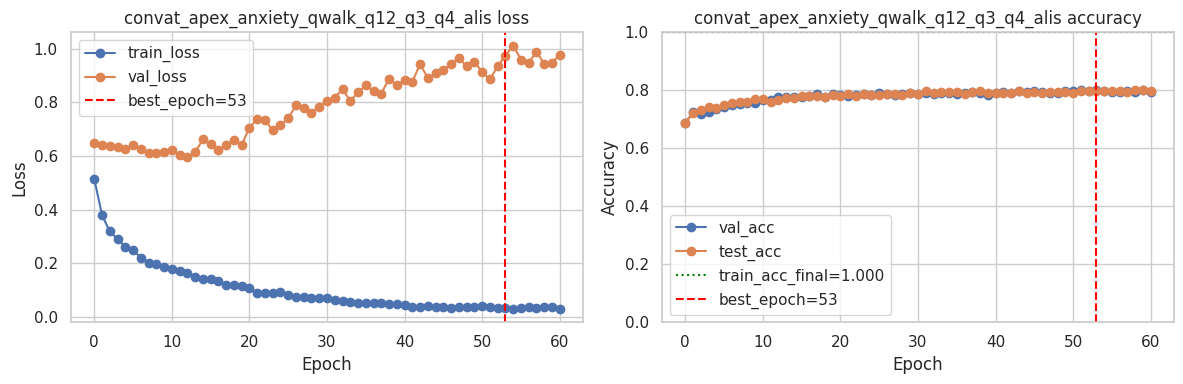

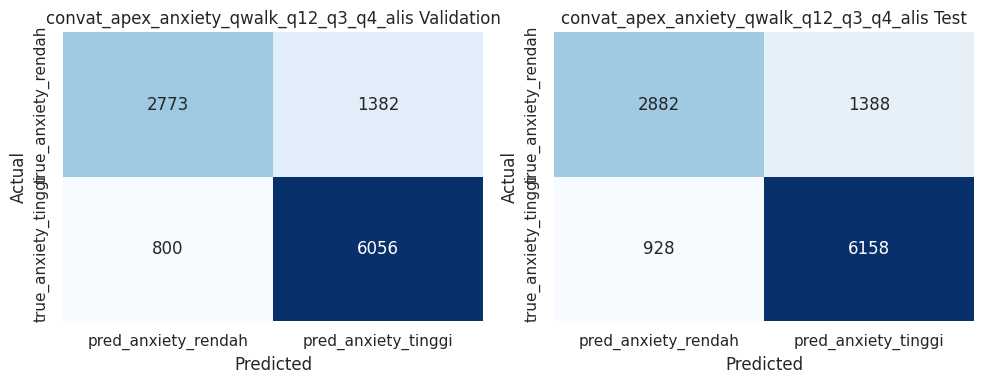

In [9]:
plot_training_curves(result_qwalk_a['result'], cfg_qwalk_a['exp_name'])
plot_confusions(result_qwalk_a['result'], cfg_qwalk_a['exp_name'])


## Experiment 3 — qwalk q123/q4/q5


In [10]:
cfg_qwalk_b = EXPERIMENTS[2]
split_info_qwalk_b = export_official_dataset(df_raw, FEATURE_COLS, cfg_qwalk_b)
_config_qwalk_b, tuning_toml_qwalk_b = prepare_tuning_config(cfg_qwalk_b['dataset_name'], cfg_qwalk_b['exp_name'])
display(Markdown(
    f"Prepared `{cfg_qwalk_b['dataset_name']}` / `{cfg_qwalk_b['exp_name']}`\n\n"
    f"- train: `{cfg_qwalk_b['train_questions']}`\n"
    f"- val: `{cfg_qwalk_b['val_questions']}`\n"
    f"- test: `{cfg_qwalk_b['test_questions']}`\n"
    f"- tuning: `{tuning_toml_qwalk_b}`"
))
del split_info_qwalk_b


Prepared `convat_apex_anxiety_qwalk_q123_q4_q5_alis` / `convat_apex_anxiety_qwalk_q123_q4_q5_alis`

- train: `(1, 2, 3)`
- val: `(4,)`
- test: `(5,)`
- tuning: `/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/third_party/tabular-dl-tabr-official/exp/tabr/convat_apex_anxiety_qwalk_q123_q4_q5_alis/0-tuning.toml`

In [ ]:
print('RUN:', cfg_qwalk_b['exp_name'])
bin.go.main(
    tuning_toml_qwalk_b,
    n_seeds=N_EVAL_SEEDS,
    n_ensembles=N_ENSEMBLES,
    ensemble_size=ENSEMBLE_SIZE,
    continue_=True,
    force=False,
)


In [12]:
summary_qwalk_b, result_qwalk_b = evaluate_experiment(cfg_qwalk_b)
display(summary_qwalk_b.sort_values(['split', 'accuracy'], ascending=[True, False]))


,mode,dataset_name,exp_name,train_questions,val_questions,test_questions,split,accuracy,macro_f1,weighted_f1,precision_tinggi,recall_tinggi,best_epoch,best_seed
2,qwalkforward,convat_apex_anxiety_qwalk_q123_q4_q5_alis,convat_apex_anxiety_qwalk_q123_q4_q5_alis,1-2-3,4,5,test,0.828686,0.813201,0.828862,0.869183,0.864797,64,11
0,qwalkforward,convat_apex_anxiety_qwalk_q123_q4_q5_alis,convat_apex_anxiety_qwalk_q123_q4_q5_alis,1-2-3,4,5,train,0.999108,0.999055,0.999108,0.999594,0.998962,64,11
1,qwalkforward,convat_apex_anxiety_qwalk_q123_q4_q5_alis,convat_apex_anxiety_qwalk_q123_q4_q5_alis,1-2-3,4,5,val,0.839556,0.829281,0.839667,0.873016,0.869320,64,11


In [13]:
ensemble_rows_qwalk_b = []
ensemble_root_qwalk_b = EXP_ROOT / cfg_qwalk_b['exp_name'] / f'0-ensemble-{ENSEMBLE_SIZE}'
if ensemble_root_qwalk_b.exists():
    for ensemble_dir in sorted([x for x in ensemble_root_qwalk_b.iterdir() if x.is_dir()]):
        report_path = ensemble_dir / 'report.json'
        if not report_path.exists():
            continue
        report = json.loads(report_path.read_text())
        ensemble_rows_qwalk_b.append({
            'exp_name': cfg_qwalk_b['exp_name'],
            'ensemble_id': ensemble_dir.name,
            'train_score': report['metrics']['train']['score'],
            'val_score': report['metrics']['val']['score'],
            'test_score': report['metrics']['test']['score'],
        })
ensemble_df_qwalk_b = pd.DataFrame(ensemble_rows_qwalk_b)
if len(ensemble_df_qwalk_b):
    display(ensemble_df_qwalk_b.sort_values(['test_score', 'val_score'], ascending=False))
else:
    print('Belum ada output ensemble.')


,exp_name,ensemble_id,train_score,val_score,test_score
2,convat_apex_anxiety_qwalk_q123_q4_q5_alis,2,1.0,0.856199,0.856664
0,convat_apex_anxiety_qwalk_q123_q4_q5_alis,0,1.0,0.858753,0.856376
1,convat_apex_anxiety_qwalk_q123_q4_q5_alis,1,1.0,0.858137,0.853981


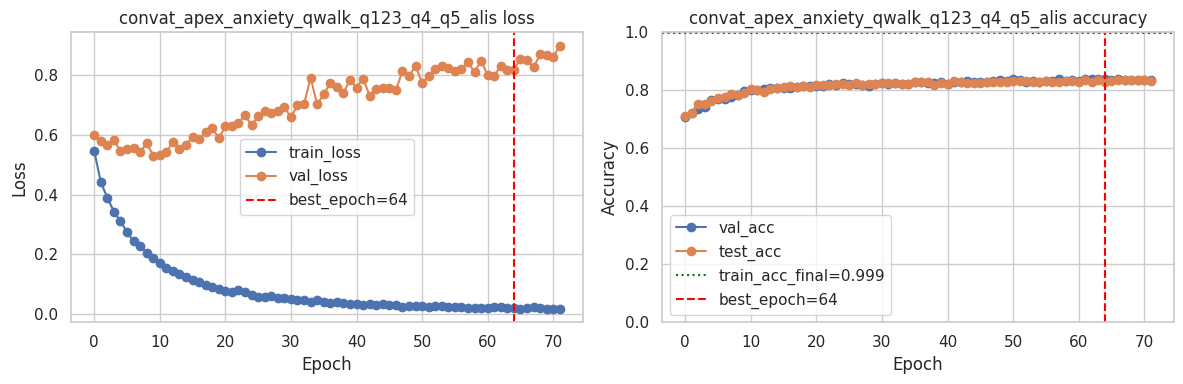

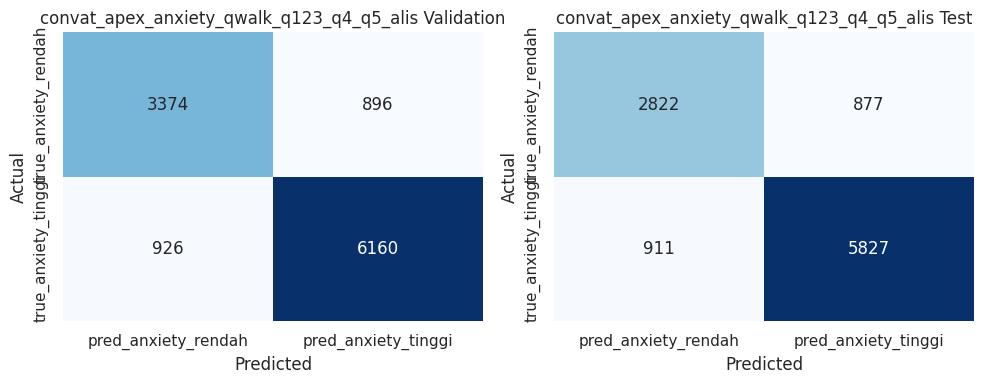

In [14]:
plot_training_curves(result_qwalk_b['result'], cfg_qwalk_b['exp_name'])
plot_confusions(result_qwalk_b['result'], cfg_qwalk_b['exp_name'])


## Compare all experiments


In [15]:
compare_df = pd.concat([summary_qholdout, summary_qwalk_a, summary_qwalk_b], ignore_index=True)
display(compare_df.sort_values(['split', 'accuracy', 'macro_f1'], ascending=[True, False, False]))


NameError: name 'summary_qholdout' is not defined

## Plot one selected run


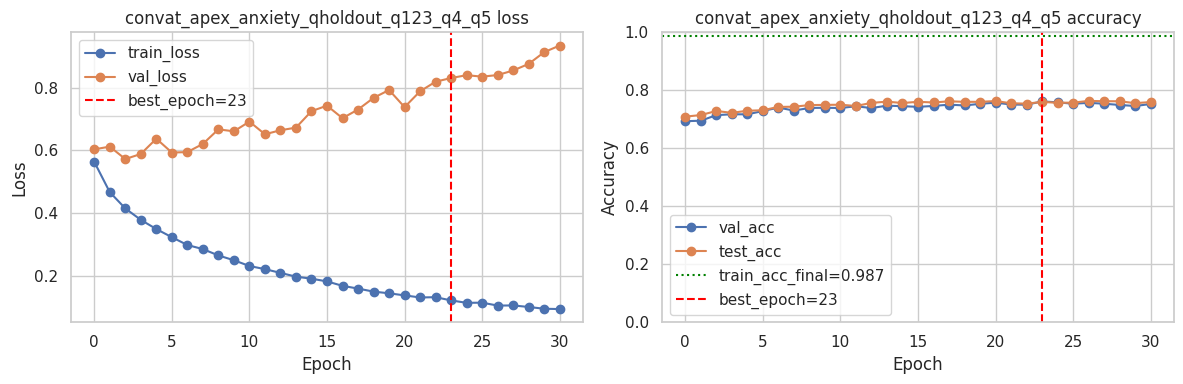

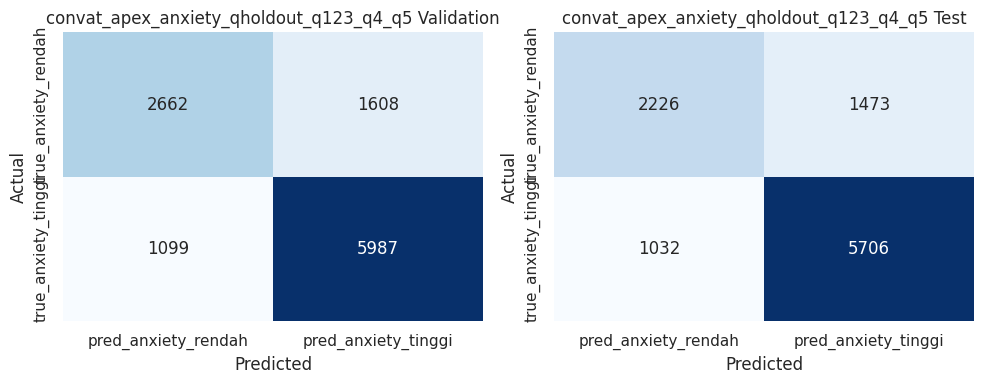

In [ ]:
SELECT_RESULT = result_qholdout  # result_qholdout / result_qwalk_a / result_qwalk_b
plot_training_curves(SELECT_RESULT['result'], SELECT_RESULT['cfg']['exp_name'])
plot_confusions(SELECT_RESULT['result'], SELECT_RESULT['cfg']['exp_name'])
